<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
Q-Learning Algorithm

## **Aim**
To implement the Q-Learning algorithm on a standard Reinforcement Learning environment using ε-greedy exploration and compare its performance with SARSA.

## **Theory**
Q-Learning is an off-policy Temporal Difference learning algorithm used to learn the optimal action-value function.

The Q-value represents the expected future reward for taking an action in a particular state.

The Q-Learning update equation is:

Q(S,A) ← Q(S,A) + α[R + γ max Q(S',A') − Q(S,A)]

where:

Q(S,A) = Current Q-value
α = Learning rate
R = Reward received
γ = Discount factor
S' = Next state
max Q(S',A') = Maximum Q-value for the next state

Q-Learning is called an off-policy algorithm because it learns the optimal policy independently of the policy used to select actions during exploration.

An ε-greedy strategy is used for exploration.

With probability ε, the agent selects a random action.

With probability (1 - ε), the agent selects the action with the highest Q-value.

In this experiment, Q-Learning is implemented on the Taxi environment. The learned policy is evaluated and compared with SARSA.

## **Algorithm**

1. Create the Taxi environment.

2. Initialize the Q-table with zeros.

3. Set the learning rate α, discount factor γ, and exploration probability ε.

4. Reset the environment and obtain the initial state.

5. Select an action using the ε-greedy policy.

6. Perform the selected action.

7. Observe the reward and next state.

8. Find the maximum Q-value of the next state.

9. Update the Q-value using:

   Q(S,A) ← Q(S,A) + α[R + γ max Q(S',A') − Q(S,A)]

10. Move to the next state.

11. Repeat until the episode terminates.

12. Gradually reduce ε to decrease exploration.

13. Repeat the training process for multiple episodes.

14. Evaluate the learned Q-Learning policy without exploration.

15. Compare Q-Learning performance with SARSA.

## **Import Required Libraries**

In [1]:
!pip install gymnasium -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## **Create Taxi Environment**

In [2]:
env = gym.make("Taxi-v4")

print("Environment:", env.spec.id)
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

print("\nActions:")
print("0 = South")
print("1 = North")
print("2 = East")
print("3 = West")
print("4 = Pickup")
print("5 = Dropoff")

Environment: Taxi-v4
Number of states: 500
Number of actions: 6

Actions:
0 = South
1 = North
2 = East
3 = West
4 = Pickup
5 = Dropoff


## **Initialize Q-Learning Parameters**

In [3]:
## **Initialize Q-Learning Parameters**

n_states = env.observation_space.n
n_actions = env.action_space.n

# Initialize Q-table
Q = np.zeros((n_states, n_actions))

# Learning parameters
alpha = 0.1
gamma = 0.99

# Exploration parameters
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

# Training episodes
n_episodes = 10000

episode_rewards = []
episode_steps = []

print("Learning Rate (alpha):", alpha)
print("Discount Factor (gamma):", gamma)
print("Initial Epsilon:", epsilon)
print("Training Episodes:", n_episodes)

Learning Rate (alpha): 0.1
Discount Factor (gamma): 0.99
Initial Epsilon: 1.0
Training Episodes: 10000


## **Define ε-Greedy Action Selection**

In [4]:
## **Define ε-Greedy Action Selection**

def choose_action(state, epsilon):

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    return np.argmax(Q[state])

## **Train Agent Using Q-Learning**

In [5]:
## **Train Agent Using Q-Learning**

for episode in range(n_episodes):

    state, info = env.reset()

    total_reward = 0
    steps = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Select action using epsilon-greedy
        action = choose_action(
            state,
            epsilon
        )

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        steps += 1

        # Q-Learning update
        if terminated or truncated:

            target = reward

        else:

            target = (
                reward
                + gamma * np.max(Q[next_state])
            )

        Q[state, action] += alpha * (
            target - Q[state, action]
        )

        state = next_state

    episode_rewards.append(total_reward)
    episode_steps.append(steps)

    # Reduce exploration
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

print("Q-Learning training completed.")
print("Final Epsilon:", round(epsilon, 4))

Q-Learning training completed.
Final Epsilon: 0.01


## **Calculate Moving Average**

In [6]:
## **Calculate Moving Average Reward**

window = 100

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

print("Moving average calculated.")

Moving average calculated.


## **Plot Training Performance**

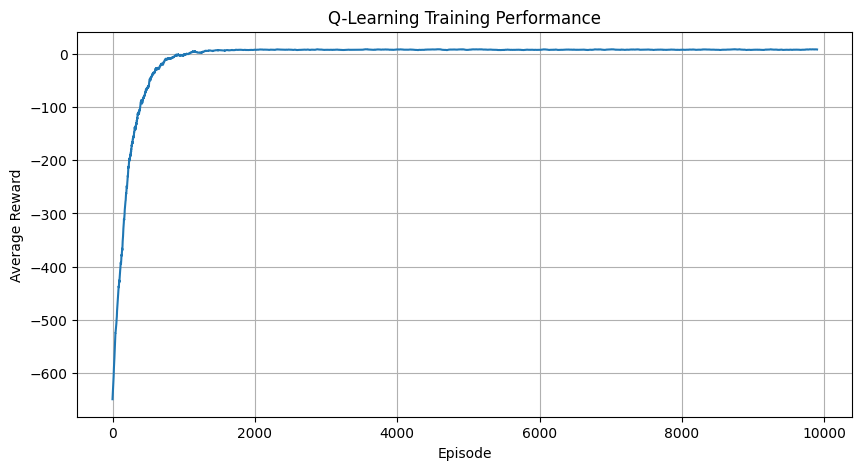

In [7]:
## **Plot Q-Learning Training Performance**

plt.figure(figsize=(10, 5))

plt.plot(
    moving_average
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "Q-Learning Training Performance"
)

plt.grid(True)

plt.show()

## **Evaluate Q-Learning Policy**

In [8]:
## **Evaluate Q-Learning Policy**

n_eval_episodes = 1000

evaluation_rewards = []
evaluation_steps = []

for episode in range(n_eval_episodes):

    state, info = env.reset()

    total_reward = 0
    steps = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Greedy action selection
        action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        steps += 1

        state = next_state

    evaluation_rewards.append(total_reward)
    evaluation_steps.append(steps)

successful_episodes = sum(
    reward > 0
    for reward in evaluation_rewards
)

print("========== Q-LEARNING EVALUATION ==========")

print(
    "Average Reward:",
    round(np.mean(evaluation_rewards), 3)
)

print(
    "Average Steps:",
    round(np.mean(evaluation_steps), 2)
)

print(
    "Successful Episodes:",
    successful_episodes
)

print(
    "Success Rate:",
    round(
        successful_episodes
        / n_eval_episodes * 100,
        2
    ),
    "%"
)

========== Q-LEARNING EVALUATION ==========
Average Reward: 7.921
Average Steps: 13.08
Successful Episodes: 1000
Success Rate: 100.0 %


## **Display Sample Q-Values**

In [9]:
## **Display Sample Q-Values**

print("========== SAMPLE Q-TABLE VALUES ==========")

for state in range(10):

    best_action = np.argmax(Q[state])

    print(
        f"State {state}: "
        f"Q-values = {np.round(Q[state], 2)} | "
        f"Best Action = {best_action}"
    )

========== SAMPLE Q-TABLE VALUES ==========
State 0: Q-values = [0. 0. 0. 0. 0. 0.] | Best Action = 0
State 1: Q-values = [-3.78 -1.63 -2.12 -2.26  9.62 -7.54] | Best Action = 4
State 2: Q-values = [-1.53  0.9  -0.79 -1.98 14.12 -5.54] | Best Action = 4
State 3: Q-values = [-3.62 -1.02 -0.93 -2.2  10.73 -5.88] | Best Action = 4
State 4: Q-values = [ -7.16  -7.18  -0.28  -7.21  -8.92 -10.15] | Best Action = 2
State 5: Q-values = [0. 0. 0. 0. 0. 0.] | Best Action = 0
State 6: Q-values = [ -7.77  -7.75  -1.13  -7.82  -9.85 -11.17] | Best Action = 2
State 7: Q-values = [-5.71 -5.69  1.92 -5.77 -6.09 -9.05] | Best Action = 2
State 8: Q-values = [ 8.92 -3.99 -3.98 -3.98 -9.19 -8.52] | Best Action = 0
State 9: Q-values = [ 3.71 -5.78 -5.84 -5.74 -8.98 -9.38] | Best Action = 0


## **Train SARSA for Comparison**

In [10]:
## **Train SARSA for Comparison**

Q_sarsa = np.zeros(
    (n_states, n_actions)
)

epsilon = 1.0

sarsa_rewards = []

for episode in range(n_episodes):

    state, info = env.reset()

    # Initial action
    if np.random.random() < epsilon:
        action = env.action_space.sample()
    else:
        action = np.argmax(Q_sarsa[state])

    total_reward = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        if terminated or truncated:

            target = reward

        else:

            # Select next action using epsilon-greedy
            if np.random.random() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax(Q_sarsa[next_state])

            # SARSA update
            target = (
                reward
                + gamma * Q_sarsa[next_state, next_action]
            )

        Q_sarsa[state, action] += alpha * (
            target - Q_sarsa[state, action]
        )

        if not (terminated or truncated):

            state = next_state
            action = next_action

    sarsa_rewards.append(total_reward)

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

print("SARSA training completed.")

SARSA training completed.


## **Compare Q-Learning and SARSA**

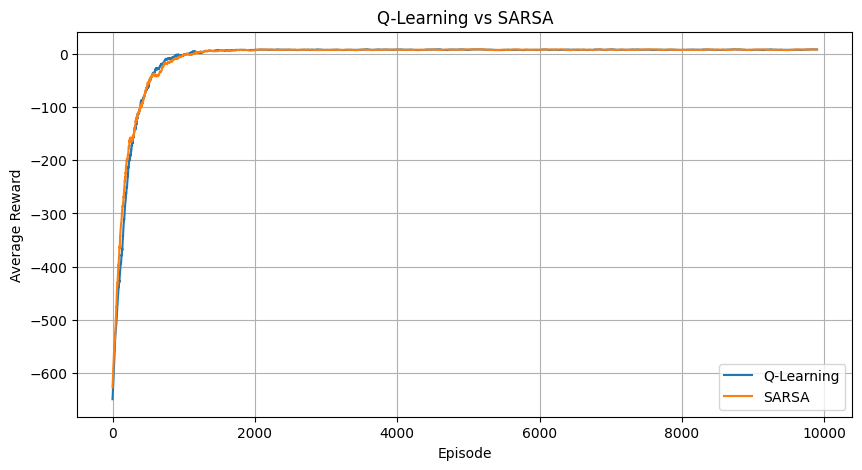

In [11]:
## **Compare Q-Learning and SARSA**

q_learning_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

sarsa_average = np.convolve(
    sarsa_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    q_learning_average,
    label="Q-Learning"
)

plt.plot(
    sarsa_average,
    label="SARSA"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "Q-Learning vs SARSA"
)

plt.legend()
plt.grid(True)

plt.show()

## **Final Performance Comparison**

In [12]:
## **Final Performance Comparison**

print("========== FINAL PERFORMANCE COMPARISON ==========")

print(
    "Q-Learning Average Reward "
    "(last 1000 episodes):",
    round(
        np.mean(episode_rewards[-1000:]),
        3
    )
)

print(
    "SARSA Average Reward "
    "(last 1000 episodes):",
    round(
        np.mean(sarsa_rewards[-1000:]),
        3
    )
)

if np.mean(episode_rewards[-1000:]) > np.mean(sarsa_rewards[-1000:]):

    print("\nQ-Learning achieved the higher average training reward.")

elif np.mean(episode_rewards[-1000:]) < np.mean(sarsa_rewards[-1000:]):

    print("\nSARSA achieved the higher average training reward.")

else:

    print("\nBoth algorithms achieved similar average rewards.")

========== FINAL PERFORMANCE COMPARISON ==========
Q-Learning Average Reward (last 1000 episodes): 7.424
SARSA Average Reward (last 1000 episodes): 7.488

SARSA achieved the higher average training reward.


## **Observation**

1. The Taxi-v4 environment was successfully used for Q-Learning.

2. A Q-table was initialized for all states and actions.

3. The agent used ε-greedy exploration during training.

4. Q-Learning updated its Q-values using the maximum Q-value of the next state.

5. The agent gradually reduced exploration as training progressed.

6. After training, the learned policy was evaluated using greedy action selection.

7. SARSA was also trained for comparison.

8. Both Q-Learning and SARSA were able to learn useful policies for the Taxi environment.

9. The performance graph allows the learning behavior of the two algorithms to be compared.

## **Conclusion**

The Q-Learning algorithm was successfully implemented on the Taxi-v4 environment using ε-greedy exploration.

The agent learned an action-value function through repeated interaction with the environment and obtained a policy by selecting the action with the highest Q-value.

Q-Learning was also compared with SARSA to observe the difference between off-policy and on-policy Temporal Difference learning.